# Мататематички методи за машинско учење 2025/2026

## Домаћи задатак број 3

<div class="alert alert-block alert-danger">
<b>Име и презиме студента:</b> Danilo Milošević

<b>Број индекса:</b> 1732
    
</div>    

<div class="alert alert-block alert-info">
<b>Упутство за израду и предају домаћег задатака: </b> 
    
    1. Пре почетка израде промените име датотеке у 03Domaci_Ime_Prezime. (убаците своје име и презиме) 
    2. Попуните ћелију испод наслова одговарајућим подацима. 
    1. Употреба ћирилице није обавезна за предају домаћег задатка.
    4. За решавање задатака, уколико је потребно, отворите испод текста задатка додатне ћелије за уписивање текстуалног одговора (Markdown) или програмског кода (Code).
    1. Сва израчунавања, уколико је потребно, вршити у Python-у.
    5. Након завршетка израде решења домаћег Notebook документ сачувати у pdf формату и проследити га наставнику. То можете да урадите или кроз Teams или на мејл адресу jovana.dzunic@elfak.ni.ac.rs

</div> 

In [2]:
import numpy as np
import numpy.random as rndm
import matplotlib as mplb
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs

**Задатак 1.** У стандардном  K-means алгоритму, сваки податак припада искључиво једном кластеру. Нека је дат скуп података $X\in\mathbb{R}^{d\times N}$ где је $d$ димензија података, а $N$ број података (подаци су колоне матрице $X$). Нека је $K$ број жељених кластера. Циљ K-means алгоритма је минимизација функције инерције $$inercija=\sum_{i=1}^K\sum_{x_j\in C_i}\|x_j-c_i\|^2.$$ 
Корак ажурирања центара може да се запише у матричној форми. Најпре уводимо матрице које у том изразу учествују.

Нека је $H\in\{0,1\}^{K\times N}$ тзв. индикаторска матрица - бинарна матрица која за сваки податак бележи да ли је елемент кластера,
$$H(i,j)=\begin{cases}1,& i-{\rm том\ кластеру\ припада\ } j-{\rm ти\ податак}\\
0,& {\rm иначе}\end{cases}$$

**а)** Нека је $C\in\mathbb{R}^{d\times K}$ матрица чије колоне чувају координате центара $c_i$ кластера $C_i.$ У новој итерацији дошло је до прерасподеле података по кластерима, то је садржај ажуриране матрице $H.$ Анализирати структуру матрице $M=HH^T:$ Да ли је она пуна, дијагонална или блок матрица? Шта представљају елементи на њеној дијагонали а шта су вандијагонални елементи?

(5 поена)

Kako svaki podatak može pripadati samo jednom klasteru, znači da svaka kolona matrice $H$ ima samo 1 jedinicu, dok su sve ostale vrednosti nule (redovi su klasteri, kolone su podaci).

U tom slučaju
\begin{align*}
M &= HH^T\\
M_{i, j} &= \sum_k H_{i, k} H_{j,k}\\
\boxed{i = j}&\\
M_{i, i} &= \sum_k H_{i, k} H_{i,k}\\
M_{i, i} &= \sum_k H_{i, k}^2 \Rightarrow M_{i, i} = \sum_k H_{i, k}\\
\Rightarrow M_{i, i} &= broj\_podataka\_u\_klasteru\_i\\
\\
\boxed{i \neq j}&\\
M_{i, j} &= \sum_k H_{i, k} H_{j,k}\\
H_{i, k} &= 0 \lor H_{j, k} = 0 \\
\Rightarrow M_{i, j} &= 0
\end{align*}

$M_{i, i}$ je broj podataka u klasteru $i$, s obzirom da je jednaka sumi u vrsti $i$ ($H_{i, k}$), pri čemu svaki element ukazuje da li podatak pripada klasteru $i$.

$M_{i, j}, i \neq j$ je uvek 0. Kako podatak $k$ može pripadati samo jednom klasteru, ili klasteru $i$ ili klasteru $j$, onda je ili $H_{i, k}$ ili $H_{j, k}$ nula, pa je i element matrice $M$ nula.

Zato je matrica $M$ **dijagonalna**

In [12]:
K = 3
N = 10
H = np.zeros((K, N))
H[rndm.randint(0, K, N), np.arange(N)] = 1

M = H @ H.T
print(M)
print("Broj elemenata po klasteru):", np.diag(M))
print("Vandijagonalni elementi ~0:", np.allclose(M - np.diag(np.diag(M)), 0))

[[1. 0. 0.]
 [0. 3. 0.]
 [0. 0. 6.]]
Broj elemenata po klasteru): [1. 3. 6.]
Vandijagonalni elementi ~0: True


**б)** Потребно је одредити нове центре кластера као центре скупа вектора по кластерима. 
Показати (извођењем или образложењем) да се координате нових центара кластера могу добити решавањем матричне једначине по $C:$
$$C(HH^T)=XH^T\quad\iff\quad CM=XH^T.$$

(5 поена)

**в)** У напреднијим алгоритмима кластеризације (нпр. *Gaussian Mixture Models* или *Fuzzy C-means*) информације о припадности кластеру нису "црно-беле" већ носе опис могућности припадања једног податка свим кластерима. То се најчешће изражава вероватноћом припадности елемента кластерима. Индикаторска матрица је сада $H\in[0,1]^{K\times N}$ са својством да је збир елемената дуж сваке колоне једнак $1,$
$$H(i,j)={\rm вероватноћа\ да\ }j-{\rm ти\ податак\ припада\ }i-{\rm том\ кластеру}\in[0,1].$$
$$\displaystyle\sum_{i=1}^K H_{ij} = 1{\ \rm за\ свако\ }j$$
*$[0,1]$ је сегмент са реалне праве, $\{0,1\}$ је двоелементни скуп!*

Претпоставка је да ниједан од кластера није без елемената, тј. да су вероватноће свих елемената за њега једнаке $0.$

Анализирати структуру матрице $M=HH^T:$ Да ли је она пуна, дијагонална или блок матрица? Шта представљају елементи на њеној дијагонали а шта су вандијагонални елементи?

(5 поена)

**г)** У овом типу класреовања израчунавање центара кластера више није проста аритметичка средина вектора из самог кластера већ тежинска средња вредност,
$$c_i=\dfrac{\displaystyle\sum_{j=1}^NH_{ij}x_j}{\displaystyle\sum_{j=1}^NH_{ij}}.$$
Уводи се дијагонална матрица тежина:
$$
D = \mathrm{diag}\Big(\sum_{j}H_{1j},\dots,\sum_{j}H_{Kj}\Big),
$$


Показати (извођењем или образложењем) да се координате нових центара кластера могу и сада добити решавањем матричне једначине по $C:$
$$CD=XH^T.$$

(5 поена)

**д)** Сада је потребно да се симулира поступак кластеризације у коме се припадност тачака кластерима одређује преко **вероватноћа** према правилима описаним у претходном делу задатака. 

1. **Генерисање података**  
   Креирати 2D скуп података коришћењем функције `make_blobs`.  
   - Број кластера: 3  
   - Број тачака: 300  
   - Стандардна девијација кластера по избору  
   - Опционо: насумично seed ради репродуктивности резултат  
   
(2 поена)   

2. **Иницијализација матрице центара**  
   Иницијализовати матрицу центара  
  $$
   C^{(0)} \in \mathbb{R}^{2 \times 3}
  $$  
   насумичним избором три тачке из скупа података или униформно из опсега података.  
   
(3 поена)   

3. **Итеративно ажурирање (5 итерација)**  
   Извршити укупно **5 итерација** поступка.  

   У свакој итерацији:  
- Израчунавање матрице припадности

    Прво се израчуна привремена матрица $\tilde H^{(t)}$ према инверзним квадратима растојања (са малим $\varepsilon$ ради стабилности):
    $$
    \tilde H^{(t)}_{ij} \;=\; \frac{1}{\|x_j - c_i^{(t)}\|^2 + \varepsilon},\qquad
    \varepsilon=10^{-8}.
    $$
    Затим се нормализује по колонама да би свака колона имала збир једнак $1:$
    $$
       H^{(t)}_{ij} \;=\; \frac{\tilde H^{(t)}_{ij}}{\displaystyle\sum_{p=1}^K \tilde H^{(t)}_{pj}}.
    $$
    Ово гарантује да је $H^{(t)}\in[0,1]^{K\times N}$ и да важи
$$
\sum_{i=1}^K H^{(t)}_{ij}=1 \quad \text{за свако } j.
$$ 

- Ажурирајте матрицу центара коришћењем формуле:  
$$
     C^{(t+1)} = X {H^{(t)}}^T \left( H^{(t)} {H^{(t)}}^T \right)^{-1}.
$$

(5 поена)

4. **Приказ резултата**  
   - Након сваке итерације нацртати:  
     - тачке података у 2D равни,  
     - тренутно израчунате центре,  
     - боју тачака одредити према кластеру са највећом вероватноћом.  
   - По завршетку 5 итерација приказати завршне центре.  
   
(5 поена)   

5. **Конвергенција**

Након извршених 5 итерација, потребно је **додатно покренути алгоритам** све док се не испуни критеријум конвергенције:
$$
\max_i \| c_i^{(t+1)} - c_i^{(t)} \| < 10^{-4},
$$
или док се не достигне максималан број итерација (`max_iter = 500`).

Треба коментаристаи:
- укупан број итерација до конвергенције,
- да ли се положаји центара након првих 5 итерација значајно разликују од стања после конвергенције,
- кратак коментар о стабилности и понашању алгоритма; Да ли се центри брзо стабилизују? Да ли је алгоритам осетљив на почетне центре? Да ли су вероватноће понекад „превише меке“ или „превише оштре“? Да ли се центри "здраво" распоређују или склизну у неку регију? Да ли се међусобно приближавају?

(10 поена)

***

**Здадатак 2.** K-means алгоритам је моћан и брз, али почива на одређеним геометријским претпоставкама. Овај задатак илуструје шта се дешава када се геометрија података не поклапа са метриком коју алгоритам користи.

Користићемо синтетички скуп података **"Two Moons"** који се састоји од два уланчана полумесеца. Ови подаци нису линеарно раздвојиви.

In [2]:
from sklearn.datasets import make_moons

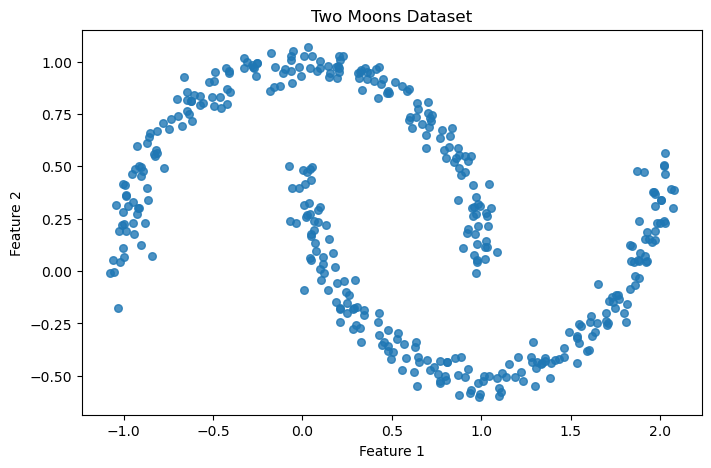

In [4]:
# Generisanje podataka
X_moons, y_moons = make_moons(n_samples=400, noise=0.05, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X_moons[:,0], X_moons[:,1], s=30, alpha=0.8)
plt.title("Two Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2");

**а)** Примена K-means алгоритма 

Применити K-means алгоритам са \(K=2\) над овим скупом података.  
Визуелизовати резултат на **Scatter plot-у**:  
- Обојити тачке различитим бојама у зависности од додељеног кластера.  
- Јасно означити положаје добијених центара (нпр. црвеним `'X'` маркером).  

(5 поена)

**б)** 
Резултат који сте добили у претходном кораку вероватно није интуитивно исправан  
(кластери „секу“ природне облике полумесеца).  

Дајте математичко и геометријско објашњење овог феномена одговарајући на следећа питања:

#### Граница раздвајања кластера (граница одлучивања)
Граница између два кластера чине тачке $x$ које су подједнако удаљене од оба центра $c_1$ и $c_2.$  

Описано једначином:
$$
\|x - c_1\|^2 = \|x - c_2\|^2
$$

**Питање:** Шта геометријски представља ова једначина у $\mathbb{R}^2?$

(2 поена)

#### Закључак
Зашто K-means не може да раздвоји ова два полумесеца, без обзира на иницијализацију? Коју геометријску карактеристику показују кластери?

(3 поена)

**в)** Спектрално кластеровање као алтернатива (5 поена)

Проблем „месеца“ се решава променом простора у коме посматрамо податке или променом метрике.  

Иако ћемо математику иза овога (сопствене вредности Лапласијана графа) радити касније, овде демонстрирајте решење позивом готове функције.

(5 поена)

In [ ]:
from sklearn.cluster import KMeans, SpectralClustering

In [ ]:
sc = SpectralClustering(n_clusters=2, affinity='nearest_neighbors')
labels = sc.fit_predict(X)

***

**Задатак 3.** Дат је скуп података који садржи информације о карактеристикама производа у продавници: цена производа, тежина производа и оцена корисника. Применом K-means алгоритма групишите производе у кластере. Одредите број кластера користећи мере квалитета кластеризације. 

(5 поена)

In [6]:
N=rndm.randint(200,450) #ukupan broj proizvoda
cena=rndm.normal(500,100,N)
tezina=rndm.normal(1000,200,N) #tezina u gramima
ocena=rndm.uniform(1,5,N)
podaci=np.block([[cena],[tezina],[ocena]]).T
podaci.shape

(262, 3)

За анализу добијених резултата кластеризације можете да користите графички приказ 3D или 2D. За 2D приказ користите парове карактеристика података. Нпр. оцена корисника у функцији цене производа и слично. Припадност различитим кластерима означавате различитим бојама тачака.

(5 поена)

K-means алгоритам је осетљив на редове величина у компонентама података. Скалирајте различите вредности компоненти и проверите резултате примене K-means алгоритма над трансформисаним подацима.

(5 поена)

***

**Задатак 4.** За слику учитану наредном кодном ћелијом спровести сегментацију слике у боји употребом K-means алгоритма. Одредити број кластера на основу критеријума ваљаности кластеризације обрађених у радној свесци 15K-means.

**Објашњење :** Сегментација слике је поступак поделе слике на регионе који су релативно хомогене структуре. Пример слике и сегментиране слике дат је у наставку.

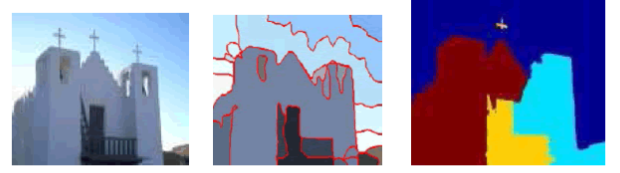

In [ ]:
import scipy.datasets as scd
rakun=scd.face()
type(rakun)

**а)** За поступак сегментације третирати сваки пиксел као вектор вредности RGB канала. Другим речима сваки пиксел је вектор тродимензионалног простора где одговарајуће компоненте означавају интензитет одговарајућег канала RGB простора слика. Упоредити добијени резултат са одговарајућом сегментацијом ако је слика дата у CIELAB простору слика. 

(5поена)

**б)** У наредном кораку сваком од пиксел-вектора (RGB и CIELAB) додати просторне координате, тј. координате положаја пиксела на слици. То је број врсте и колоне у којој се пиксел налази. На тај начин сваки пиксел постаје елемент петодимензионалног векторског простора. Спровести нову сегментацију слике употребом K-means алгоритма. 

(5 поена)

**в)** У наредном кораку скалирати све компоненте на интервал $[0,1]$ користећи информације о минимуму и максимуму дуж одговарајуће координатне осе.

(5 поена)

In [ ]:
plt.imshow(rakun);

**г)** Искористити претходни поступак сегментације за компресију учитане слике. Сваки тродимензионални пиксел-вектор заменити центром кластера коме тај пиксел припада. 

(5 поена)

Заменом сваког пиксела центром његовог кластера вршимо компресију.  
Проблем се може посматрати као складиштење матрица.

#### Оригинални формат
$$
N_{\text{pix}} \times 3 \quad (\text{float/int})
$$


#### Компресовани формат
- Матрица индекса:  
  $$
  N_{\text{pix}} \times 1 \quad (\text{int})
  $$
- Матрица центара (Codebook):  
 $$
  K \times 3 \quad (\text{float})
  $$

**д)** Израчунати уштеду меморије и приказати однос компресије за:
$$
K \in \{2, 5, 10, 20\}.
$$

(5 поена)

***